In [2]:
%load_ext ipympl
%matplotlib widget

import numpy as np
import importlib, game_3dutils,neos_path_game, ukf_estimator,game_viz, game_runner_diff #game_runner_mcp,  rl_infer
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

import torch
import os

importlib.reload(game_3dutils)
importlib.reload(neos_path_game)
importlib.reload(ukf_estimator)
importlib.reload(game_viz)
# importlib.reload(rl_infer)
importlib.reload(game_runner_diff)
# importlib.reload(game_runner_mcp)


# from game_3dutils    import run_rhc_and_collect_frames_3d, run_rhc_with_rl_and_collect_frames_3d
from game_runner_diff import run_rhc_with_rl_and_collect_frames_3d_diff
# from game_costs import build_game_costs
from game_viz import animate_rollout_3d, interactive_rollout_3d, plot_rollout_thrust_u, plot_rollout_center_distance


from dyn_models import (
    hcw_mean_motion, hcw_discrete_mats, as_numpy_const, dims_from_D,
    augment_AB_for_att, augment_bounds_with_att, pad_x0_with_att,
    frame_from_axis_continuous, world_to_body_R, apply_roll_about_axis
)

from config_rl import config_for_eval, build_dyn


The ipympl module is not an IPython extension.


In [3]:
CKPT_DIR = Path("Training_Policy")

# POLICY_DEFENDER = "def0_def_teacher.pt"             # "def#_def_ukf_student.pt" or "def#_def_teacher.pt"
POLICY_DEFENDER = "def0_def_teacher.pt"             # "def#_def_ukf_student.pt" or "def#_def_teacher.pt"
POLICY_ATTACKER = "att1_att_teacher.pt"
ATTACKER_MODE = "rule" # "rule" or "rl"
USE_UKF = False  # True or False
ROLLOUT_DYNAMICS = "hcw"    # hcw, two_body, elliptic_ltv
DELTA_T = 0.1
TOTAL_ROLLOUT_TIME = 300 #Seconds

ANIMATE_ROLLOUT = True
CREATE_GIF_AND_MP4 = False

def main():
    """
    Run one rollout using the current module-level CAPITALIZED knobs.
    Change the CAPITALIZED variables at the top of the file (or via run_with()),
    then call main().
    """
    import os
    import shutil
    from pathlib import Path

    import numpy as np

    # Only needed if you actually use GIF/MP4 writing
    import imageio.v3 as iio

    # (Optional) re-pull config "single source of truth" if you really want it fresh each call
    # NOTE: doing this repeatedly in notebooks can be confusing; safe to remove if not needed.
    # import importlib
    # import config_rl
    # importlib.reload(config_rl)

    # ---- Build cfg ----
    cfg = config_for_eval(
        attacker_mode=ATTACKER_MODE,  # "rule" or "rl"
        # umax=0.25,
        # T=600,
    )

    cfg["x0"] = np.array([
        [  2.5, 0.0, 0.0,  -0.02, 0.00, 0.000],  # defender
        [ -19.9, 0.0, 0.0,  +0.02, 0.00, 0.000], # attacker
    ], dtype=float)

    # ---- Apply rollout knobs ----
    cfg["use_ukf"]  = USE_UKF
    cfg["dynamics"] = ROLLOUT_DYNAMICS
    cfg["dt"]       = DELTA_T

    # Make horizon an INT number of steps (avoid float weirdness)
    cfg["T"] = int(round(TOTAL_ROLLOUT_TIME / DELTA_T))

    # Fill Ad/Bd (float32) from chosen dynamics
    build_dyn(cfg)

    # ---- Checkpoints ----
    cfg["ckpt_def"] = str(CKPT_DIR / POLICY_DEFENDER)

    # Only set attacker ckpt when attacker_mode is RL and you provided a filename
    if cfg.get("attacker_mode", "rule") == "rl" and POLICY_ATTACKER:
        cfg["ckpt_att"] = str(CKPT_DIR / POLICY_ATTACKER)

    print(
        "DEF ckpt?", os.path.exists(cfg["ckpt_def"]),
        "ATT ckpt?", os.path.exists(cfg.get("ckpt_att", "")),
        "| attacker_mode:", cfg.get("attacker_mode")
    )

    # ---- Run rollout ----
    steps = int(cfg["T"])
    print("steps:", steps)

    rollout = run_rhc_with_rl_and_collect_frames_3d_diff(cfg, steps=steps)

    print("Finished rollout.")

    # ---- Animate & save ----
    if CREATE_GIF_AND_MP4:
        print("Starting animation...")
        if TOTAL_ROLLOUT_TIME < 121:  # seconds
            FILE_NAME = "traj_3D_rl_1vRL"
            GIF_PATH = str(CKPT_DIR / (FILE_NAME + ".gif"))
            MP4_PATH = str(CKPT_DIR / (FILE_NAME + ".mp4"))

            print("Saving to .gif...")
            animate_rollout_3d(
                rollout,
                save_path=GIF_PATH,
                fps=20,
                cfg=cfg,
                show_fov=True,
                show_axes=True,
            )

            print("Saving to .mp4...")
            gif_frames = iio.imread(GIF_PATH)
            iio.imwrite(MP4_PATH, gif_frames, fps=20, codec="h264")
            print("Saved:", GIF_PATH, "and", MP4_PATH)
        else:
            print("Skipping animation due to large rollout size...")

    # ---- Optional interactive viewer (blocks until you close it) ----
    if ANIMATE_ROLLOUT:
        print("Starting interactive rollout...")
        interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)

    # ---- Optional cleanup (can be slow if '.' is huge; keep if you want) ----
    # If you previously saw "runs forever", consider deleting this block entirely,
    # or changing Path('.') to the script directory.
    for p in Path(".").rglob("__pycache__"):
        shutil.rmtree(p, ignore_errors=True)
    for f in Path(".").rglob("*.pyc"):
        try:
            f.unlink()
        except FileNotFoundError:
            pass

    return rollout, cfg

def run_with(**overrides):
    old = {}
    for k, v in overrides.items():
        old[k] = globals()[k]
        globals()[k] = v
    try:
        return main()          # <-- this returns (rollout, cfg)
    finally:
        for k, v in old.items():
            globals()[k] = v

DEF ckpt? True ATT ckpt? False | attacker_mode: rule
steps: 3000
Finished rollout.


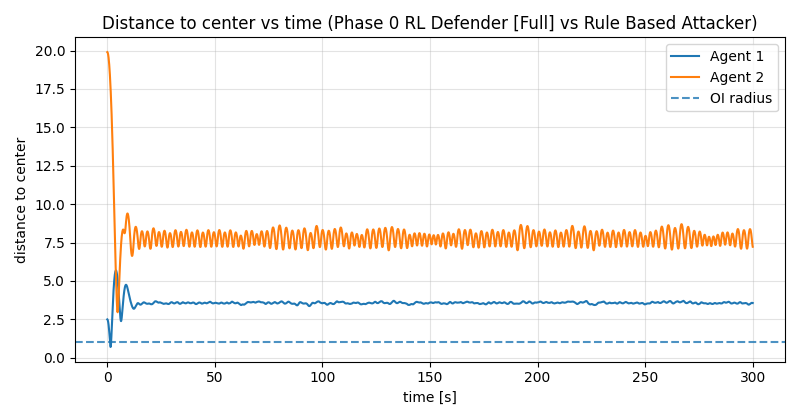

In [9]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def0_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rule",
        USE_UKF=False,
        ANIMATE_ROLLOUT=False
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 0 RL Defender [Full] vs Rule Based Attacker)")

To correct: Why is attacker logic so wack? Why is longer training so bad? How to merge logic from working scenarios in a way that makes sense

DEF ckpt? True ATT ckpt? True | attacker_mode: rl
steps: 3000
Finished rollout.


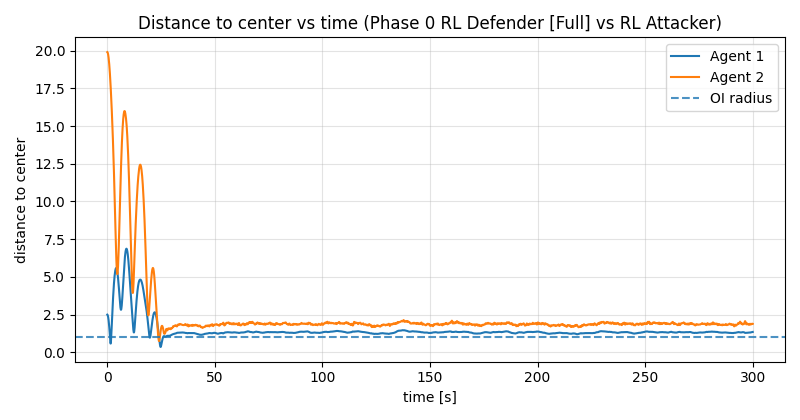

In [ ]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def0_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",
        USE_UKF=False,
        ANIMATE_ROLLOUT=True
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 0 RL Defender [Full] vs RL Attacker)")

In [34]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def0_ukf_student.pt",
        POLICY_ATTACKER="att1_att_teacher.pt",
        ATTACKER_MODE="rule",
        USE_UKF=True,
        ANIMATE_ROLLOUT=False
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 0 RL Defender [UKF] vs Rule Based Attacker)")

DEF ckpt? False ATT ckpt? False | attacker_mode: rule
steps: 3000


FileNotFoundError: Training_Policy/def0_ukf_student.pt

In [ ]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def0_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",
        USE_UKF=False,
        ANIMATE_ROLLOUT=True
    )

    # plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 1 RL Defender [Full] vs RL Attacker)")

DEF ckpt? True ATT ckpt? True | attacker_mode: rl
steps: 3000
Finished rollout.
Starting interactive rollout...


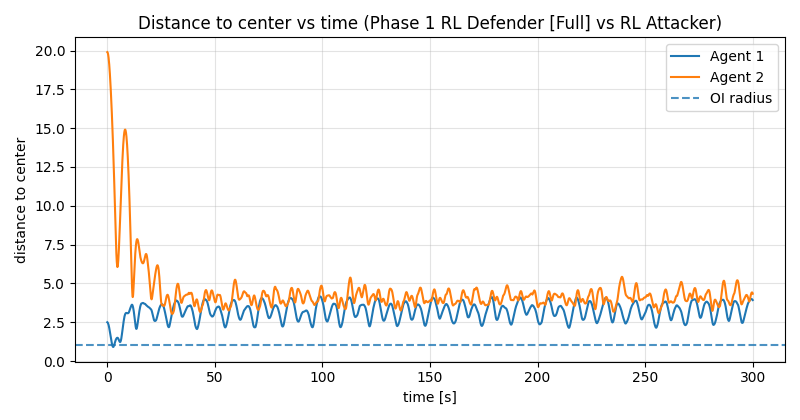

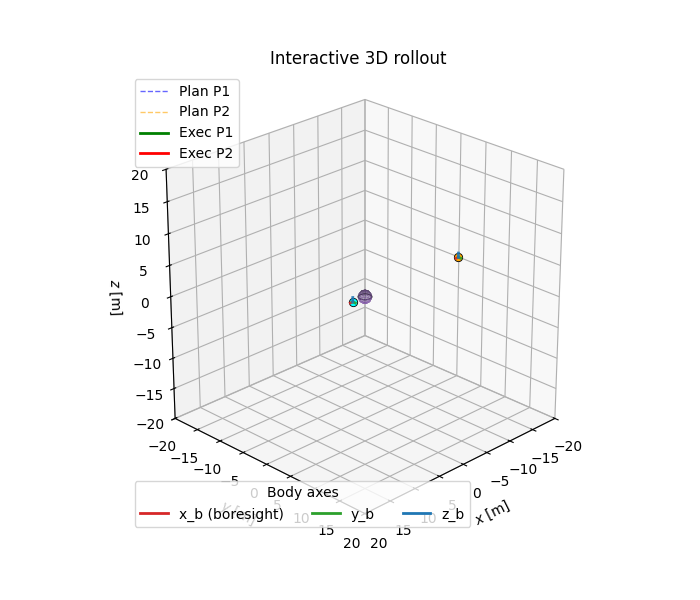

In [7]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def1_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",
        USE_UKF=False,
        ANIMATE_ROLLOUT=True
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 1 RL Defender [Full] vs RL Attacker)")

DEF ckpt? True ATT ckpt? True | attacker_mode: rl
steps: 3000
Finished rollout.


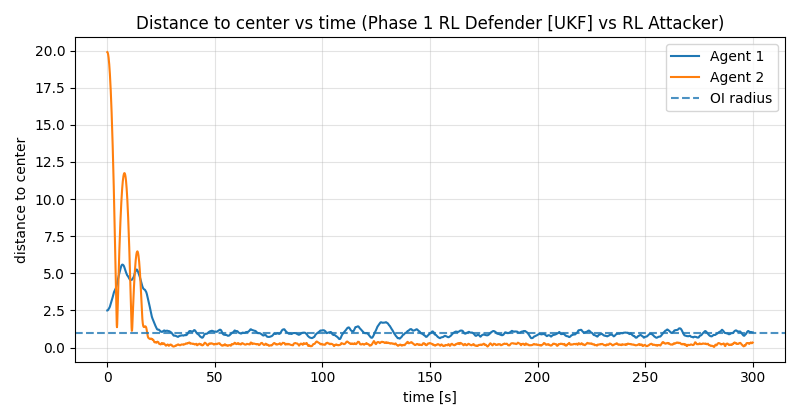

In [26]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def1_ukf_student.pt",
        POLICY_ATTACKER="att1_att_teacher.pt",
        ATTACKER_MODE="rl",
        USE_UKF=True,
        ANIMATE_ROLLOUT=False
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 1 RL Defender [UKF] vs RL Attacker)")

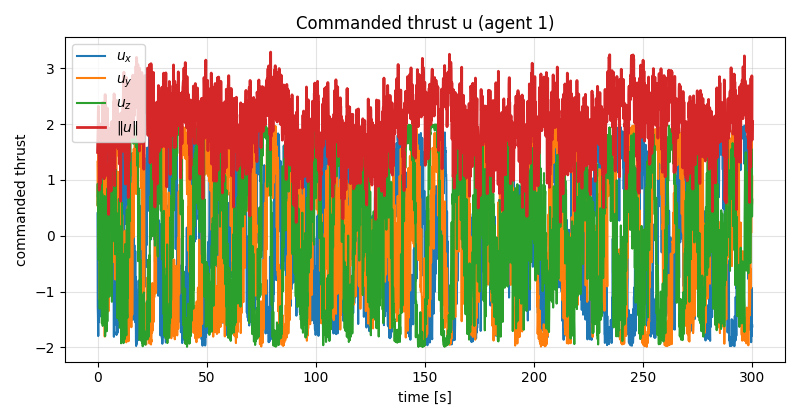

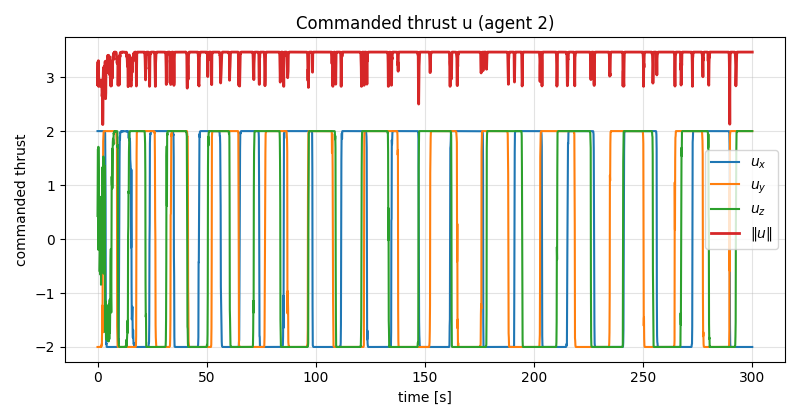

(<Figure size 800x420 with 1 Axes>,
 <Axes: title={'center': 'Commanded thrust u (agent 2)'}, xlabel='time [s]', ylabel='commanded thrust'>)

In [37]:
# After you have frames_dict from a rollout:
plot_rollout_thrust_u(rollout, cfg=cfg, agent=1)

# Agent 2:
plot_rollout_thrust_u(rollout, cfg=cfg, agent=2)

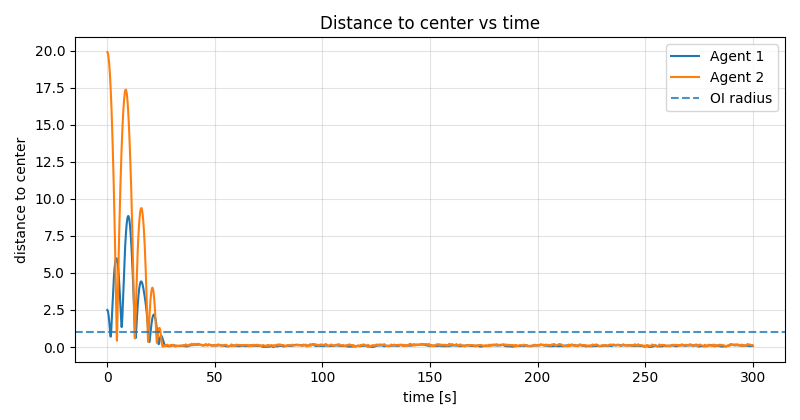

(<Figure size 800x420 with 1 Axes>,
 <Axes: title={'center': 'Distance to center vs time'}, xlabel='time [s]', ylabel='distance to center'>)

In [5]:
plot_rollout_center_distance(rollout, cfg)

In [33]:
# --- glue: build Ad/Bd, make nets, load checkpoints ---
import os, torch, numpy as np
from dyn_models import hcw_mean_motion, hcw_discrete_mats, as_numpy_const
from rl_loop import Env, ActorCritic  # same net class used in training

# 1) Build Ad/Bd exactly like training
n = hcw_mean_motion(CONFIG_RL["hcw"])
Ad, Bd = hcw_discrete_mats(float(n), float(CONFIG_RL["dt"]))
CONFIG_RL["dyn"]["Ad"] = as_numpy_const(Ad)
CONFIG_RL["dyn"]["Bd"] = as_numpy_const(Bd)

# 2) Infer obs/action dims from the Env  ✅ reset first
_tmp_env = Env(CONFIG_RL)
obs_dim = _tmp_env.reset().shape[0]   # <-- reset returns the first obs
act_dim = _tmp_env.act_dim            # or CONFIG_RL["D"]


# 3) Make tiny “ppo” holder with matching nets
class PPOHolder:
    def __init__(self, obs_dim, act_dim, device="cpu"):
        self.device  = device
        self.def_net = ActorCritic(obs_dim, act_dim).to(device)
        self.att_net = ActorCritic(obs_dim, act_dim).to(device)

ppo = PPOHolder(obs_dim, act_dim, device=CONFIG_RL["device"])

# 4) Load checkpoints (with tolerant key remap if names differ)
def _remap(sd):
    out = {}
    for k, v in sd.items():
        k = k.replace("pi_body.", "pi.").replace("mu_head.", "mu.")
        out[k] = v
    return out

def _safe_load(net, path):
    sd = torch.load(path, map_location=CONFIG_RL["device"])
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    sd = _remap(sd)
    try:
        net.load_state_dict(sd, strict=True)
    except RuntimeError:
        net.load_state_dict(sd, strict=False)  # ignore harmless unexpected keys

ck_def = "ppo_def.pt"
ck_att = "ppo_att.pt"
assert os.path.exists(ck_def) and os.path.exists(ck_att), "Missing ppo_def.pt / ppo_att.pt"
_safe_load(ppo.def_net, ck_def)
_safe_load(ppo.att_net, ck_att)
ppo.def_net.eval(); ppo.att_net.eval()


def atanh(x: torch.Tensor) -> torch.Tensor:
    x = torch.clamp(x, -0.999999, 0.999999)
    return 0.5 * (torch.log1p(x) - torch.log1p(-x))

def squash_action(u_raw: torch.Tensor, act_scale: float) -> torch.Tensor:
    return torch.tanh(u_raw) * act_scale

policy_tests.Env = Env
policy_tests.squash_action = squash_action
policy_tests.atanh = atanh
policy_tests.hcw_mean_motion = hcw_mean_motion
policy_tests.hcw_discrete_mats = hcw_discrete_mats
policy_tests.as_numpy_const = as_numpy_const

policy_tests.run_policy_tests(CONFIG_RL, ppo)

ModuleNotFoundError: No module named 'rl_loop'